In [9]:
import pandas as pd
df = pd.read_csv("house_price.csv")
print(df.head(
))

   Area  Bedroom   Bathroom  Age  Location_score    Price
0   650        1          1   20               4  1850000
1   720        2          1   15               5  2150000
2   800        2          1   18               6  2400000
3   850        2          2   10               6  2650000
4   900        2          2   12               7  2900000


In [10]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Area            9 non-null      int64
 1   Bedroom         9 non-null      int64
 2    Bathroom       9 non-null      int64
 3   Age             9 non-null      int64
 4   Location_score  9 non-null      int64
 5   Price           9 non-null      int64
dtypes: int64(6)
memory usage: 560.0 bytes
None
              Area   Bedroom   Bathroom        Age  Location_score  \
count     9.000000  9.000000   9.000000   9.000000        9.000000   
mean    891.111111  2.333333   1.666667  11.444444        6.222222   
std     150.702061  0.707107   0.500000   5.246692        1.201850   
min     650.000000  1.000000   1.000000   5.000000        4.000000   
25%     800.000000  2.000000   1.000000   8.000000        6.000000   
50%     900.000000  2.000000   2.000000  10.000000        6.000000   
75%    1000.000000

In [11]:
x=df[["Area","Bedroom"," Bathroom","Age","Location_score"]]
y=df["Price"]
print(x.shape)
print(y.shape)

(9, 5)
(9,)


In [12]:
df.dropna()
df.fillna(df.mean())
df.fillna(method = 'ffill')

,Area,Bedroom,Bathroom,Age,Location_score,Price
0,650,1,1,20,4,1850000
1,720,2,1,15,5,2150000
2,800,2,1,18,6,2400000
3,850,2,2,10,6,2650000
4,900,2,2,12,7,2900000
5,950,3,2,8,6,3100000
6,1000,3,2,9,7,3350000
7,1050,3,2,5,8,3650000
8,1100,3,2,6,7,3750000


In [13]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y, test_size = 0.2,random_state = 42)
print("Train size:",x_train . shape[0])
print("Test size:",x_test . shape[0])

Train size: 7
Test size: 2


In [15]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)
print("Coefficient:",model.coef_)
print("Intercept:",model.intercept_)

Coefficient: [  5454.54545455   8441.55844156 311038.96103896  42857.14285714
 -92857.14285714]
Intercept: -2503246.7532467507


In [16]:
y_pred = model.predict(x_test)
print(y_pred[:5])
print(y_test.values[:5])

[3342857.14285714 1930519.48051948]
[3650000 2150000]


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print("MAE:",mae,"MSE:",mse,"RMSE:",rmse,"R2:",r2)

MAE: 263311.6883116886 MSE: 71254216562.65834 RMSE: 266934.8545294494 R2: 0.8733258372219408


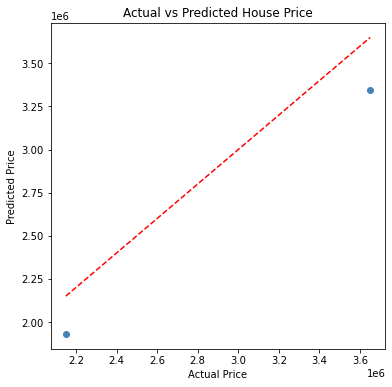

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize = (6,6))
plt.scatter(y_test,y_pred,color="steelblue")
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],"r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()